In [1]:
!nvidia-smi

Sun May 24 19:38:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q datasets transformers torch torchvision accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [3]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [4]:
SELECTED_CLASSES = [
    "caesar_salad", "greek_salad", "edamame", "miso_soup", "grilled_salmon",
    "sushi", "sashimi", "spaghetti_bolognese", "pad_thai", "chicken_curry",
    "omelette", "pancakes", "ramen",
    "pizza", "hamburger", "french_fries", "donuts", "cheesecake",
    "ice_cream", "chocolate_cake",
]

NUM_CLASSES = len(SELECTED_CLASSES)
print(f"Number of classes: {NUM_CLASSES}")

Number of classes: 20


In [5]:
print("Loading Food-101 dataset...")
ds_full = load_dataset("food101")
class_names_food101 = ds_full["train"].features["label"].names

selected_indices = [class_names_food101.index(c) for c in SELECTED_CLASSES]
print(f"Selected indices: {selected_indices}")

old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(selected_indices)}
print(f"Old->New mapping erstellt: {len(old_to_new)} Klassen")

Loading Food-101 dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

Selected indices: [11, 48, 33, 64, 50, 95, 86, 90, 70, 18, 67, 72, 81, 76, 53, 40, 31, 16, 58, 21]
Old->New mapping erstellt: 20 Klassen


In [6]:
ds_train = ds_full["train"].filter(lambda x: x["label"] in selected_indices)
ds_val = ds_full["validation"].filter(lambda x: x["label"] in selected_indices)

def relabel(example):
    example["label"] = old_to_new[example["label"]]
    return example

ds_train = ds_train.map(relabel)
ds_val = ds_val.map(relabel)

print(f"Train size: {len(ds_train)}")
print(f"Val size: {len(ds_val)}")
print(f"Label range: 0..{max(ds_train['label'])}")

Filter:   0%|          | 0/75750 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Filter:   0%|          | 0/25250 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Train size: 15000
Val size: 5000
Label range: 0..19


In [7]:
MODEL_CHECKPOINT = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(MODEL_CHECKPOINT)

def transform(example_batch):
    inputs = processor([img.convert("RGB") for img in example_batch["image"]], return_tensors="pt")
    inputs["labels"] = example_batch["label"]
    return inputs

ds_train.set_transform(transform)
ds_val.set_transform(transform)

print("Preprocessor ready")
print(f"Model checkpoint: {MODEL_CHECKPOINT}")
print(f"Image size expected: {processor.size}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Preprocessor ready
Model checkpoint: google/vit-base-patch16-224
Image size expected: {'height': 224, 'width': 224}


In [8]:
def collate_fn(batch):
    return {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
        "labels": torch.tensor([x["labels"] for x in batch]),
    }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
    }

print("Collate function and metrics defined")

Collate function and metrics defined


In [10]:
# Diagnostik + Fix
print("Train columns:", ds_train.column_names)
print("Val columns:", ds_val.column_names)
print("Sample feature keys:", list(ds_train[0].keys()))

Train columns: ['image', 'label']
Val columns: ['image', 'label']
Sample feature keys: ['pixel_values', 'labels']


In [11]:
# Diagnostik - Spalten und Sample-Inhalt checken
print("=" * 60)
print("DATASET DIAGNOSTIK")
print("=" * 60)

print("\nTrain columns:", ds_train.column_names)
print("Val columns:", ds_val.column_names)

print("\n--- Erstes Train-Sample (Keys + Types) ---")
sample = ds_train[0]
for key in sample.keys():
    val = sample[key]
    if hasattr(val, 'shape'):
        print(f"  {key}: shape={val.shape}, dtype={val.dtype}")
    elif hasattr(val, 'size'):
        print(f"  {key}: PIL Image size={val.size}")
    else:
        print(f"  {key}: {type(val).__name__} = {val}")

print("\n--- Features ---")
print(ds_train.features)

DATASET DIAGNOSTIK

Train columns: ['image', 'label']
Val columns: ['image', 'label']

--- Erstes Train-Sample (Keys + Types) ---
  pixel_values: shape=torch.Size([3, 224, 224]), dtype=torch.float32
  labels: int = 12

--- Features ---
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_y

In [12]:
# === SAUBERER RESET: Features fixen + Transform neu setzen ===
from datasets import Features, ClassLabel, Image

# Fresh-Filter aus dem Original-Dataset (nicht aus dem schon-relabelten)
ds_train = ds_full["train"].filter(lambda x: x["label"] in selected_indices)
ds_val = ds_full["validation"].filter(lambda x: x["label"] in selected_indices)

# Transform mit integriertem Relabel - das ist sauberer als .map()
def transform(example_batch):
    inputs = processor(
        [img.convert("RGB") for img in example_batch["image"]],
        return_tensors="pt",
    )
    # Relabel old indices to 0..19 inside transform (immer aktuell)
    inputs["labels"] = [old_to_new[label] for label in example_batch["label"]]
    return inputs

ds_train.set_transform(transform)
ds_val.set_transform(transform)

# Verify
sample = ds_train[0]
print("Sample keys:", list(sample.keys()))
print("Pixel values shape:", sample["pixel_values"].shape)
print("Sample label (relabelt):", sample["labels"])
print(f"\nTrain size: {len(ds_train)}, Val size: {len(ds_val)}")

# Mini-batch test (simuliert was Trainer macht)
batch = collate_fn([ds_train[0], ds_train[1], ds_train[2]])
print(f"\nBatch test:")
print(f"  pixel_values: {batch['pixel_values'].shape}")
print(f"  labels: {batch['labels']}")
print(f"  max label: {batch['labels'].max().item()}")

Sample keys: ['pixel_values', 'labels']
Pixel values shape: torch.Size([3, 224, 224])
Sample label (relabelt): 12

Train size: 15000, Val size: 5000

Batch test:
  pixel_values: torch.Size([3, 3, 224, 224])
  labels: tensor([12, 12, 12])
  max label: 12


In [13]:
# Vor dem Training: GPU Memory leeren (altes Modell weg)
import gc
try:
    del model_head
    del trainer_1
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print("GPU cleared - ready for fresh training")

GPU cleared - ready for fresh training


In [16]:
# === FINALER FIX: Defensive Transform-Funktion ===
from datasets import Image as DSImage

# Fresh-Filter
ds_train = ds_full["train"].filter(lambda x: x["label"] in selected_indices)
ds_val = ds_full["validation"].filter(lambda x: x["label"] in selected_indices)

print("Columns after filter:", ds_train.column_names)
print("Features after filter:", ds_train.features)

# Robuster Transform — kommt mit allen Edge-Cases klar
def robust_transform(example_batch):
    # Debug: zeige Keys beim ersten Call
    if not hasattr(robust_transform, '_logged'):
        print(f"DEBUG: Transform aufgerufen mit Keys: {list(example_batch.keys())}")
        robust_transform._logged = True

    # Finde Image-Spalte (manchmal 'image', manchmal 'img')
    image_key = None
    for candidate in ['image', 'img', 'images']:
        if candidate in example_batch:
            image_key = candidate
            break

    if image_key is None:
        raise ValueError(f"Keine Image-Spalte gefunden! Keys: {list(example_batch.keys())}")

    # Finde Label-Spalte
    label_key = 'label' if 'label' in example_batch else 'labels'

    inputs = processor(
        [img.convert("RGB") for img in example_batch[image_key]],
        return_tensors="pt",
    )
    inputs["labels"] = [old_to_new[label] for label in example_batch[label_key]]
    return inputs

# Reset transforms
ds_train.set_transform(robust_transform)
ds_val.set_transform(robust_transform)

# Verify mit explizitem Batch-Test
print("\n=== VERIFY ===")
sample0 = ds_train[0]
print(f"Sample 0 keys: {list(sample0.keys())}")
print(f"Sample 0 pixel shape: {sample0['pixel_values'].shape}")
print(f"Sample 0 label: {sample0['labels']}")

# Simuliere was der Trainer macht: einen Batch holen
batch = [ds_train[i] for i in range(4)]
collated = collate_fn(batch)
print(f"\nBatch shape: {collated['pixel_values'].shape}")
print(f"Batch labels: {collated['labels']}")
print("Transform funktioniert!")

Columns after filter: ['image', 'label']
Features after filter: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_ra

In [17]:
# === BULLETPROOF FIX ===
import gc

# 1. Memory clean
try:
    del model_head, trainer_1
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

# 2. Fresh datasets aus dem Original-Cache
ds_train = ds_full["train"].filter(lambda x: x["label"] in selected_indices)
ds_val = ds_full["validation"].filter(lambda x: x["label"] in selected_indices)

# 3. Transform-Funktion (sauber)
def transform(example_batch):
    inputs = processor(
        [img.convert("RGB") for img in example_batch["image"]],
        return_tensors="pt",
    )
    inputs["labels"] = [old_to_new[label] for label in example_batch["label"]]
    return inputs

# 4. WITH_TRANSFORM statt set_transform (gibt neue Variable zurück)
ds_train = ds_train.with_transform(transform)
ds_val = ds_val.with_transform(transform)

# Verify
sample = ds_train[0]
print(f"Sample keys: {list(sample.keys())}")
print(f"Pixel shape: {sample['pixel_values'].shape}")
print(f"Label: {sample['labels']}")
print("✅ Ready for training")

Sample keys: ['pixel_values', 'labels']
Pixel shape: torch.Size([3, 224, 224])
Label: 12
✅ Ready for training


In [18]:
print("="*60)
print("ITERATION 1: Head-only Fine-tuning")
print("="*60)

model_head = ViTForImageClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_CLASSES,
    id2label={i: c for i, c in enumerate(SELECTED_CLASSES)},
    label2id={c: i for i, c in enumerate(SELECTED_CLASSES)},
    ignore_mismatched_sizes=True,
)

for name, param in model_head.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_head.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_head.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

training_args_1 = TrainingArguments(
    output_dir="/content/vit_head_only",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=1e-3,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=50,
    report_to="none",
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    remove_unused_columns=False,  # KRITISCH! Verhindert dass Trainer 'image' wegwirft
)

trainer_1 = Trainer(
    model=model_head,
    args=training_args_1,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer_1.train()

eval_1 = trainer_1.evaluate()
print(f"\nIteration 1 final metrics:")
for k, v in eval_1.items():
    print(f"  {k}: {v}")

ITERATION 1: Head-only Fine-tuning


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([20, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([20])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainable params: 15,380 / 85,814,036 (0.02%)
Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.286091,0.171420,0.945400,0.945617
2,0.168414,0.154014,0.950600,0.950624
3,0.166313,0.148929,0.951200,0.951197


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Iteration 1 final metrics:
  eval_loss: 0.14892911911010742
  eval_accuracy: 0.9512
  eval_f1_macro: 0.9511971387785445
  eval_runtime: 44.2984
  eval_samples_per_second: 112.871
  eval_steps_per_second: 1.783
  epoch: 3.0


In [19]:
# Memory clean vor Iter 2
import gc
try:
    del model_head, trainer_1
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print("GPU cleared - starting Iteration 2")

print("="*60)
print("ITERATION 2: Full Fine-tuning")
print("="*60)

# Fresh model - alle Layer trainierbar
model_full = ViTForImageClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_CLASSES,
    id2label={i: c for i, c in enumerate(SELECTED_CLASSES)},
    label2id={c: i for i, c in enumerate(SELECTED_CLASSES)},
    ignore_mismatched_sizes=True,
)
# Kein freezing - alle Layer trainieren!

trainable = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_full.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

training_args_2 = TrainingArguments(
    output_dir="/content/vit_full",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,  # niedriger für full fine-tuning
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    logging_steps=50,
    report_to="none",
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    remove_unused_columns=False,  # KRITISCH
)

trainer_2 = Trainer(
    model=model_full,
    args=training_args_2,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

print("Starting full fine-tuning...")
trainer_2.train()

eval_2 = trainer_2.evaluate()
print(f"\nIteration 2 final metrics:")
for k, v in eval_2.items():
    print(f"  {k}: {v}")

GPU cleared - starting Iteration 2
ITERATION 2: Full Fine-tuning


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([20, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([20])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainable params: 85,814,036 / 85,814,036 (100.00%)
Starting full fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.319139,0.180866,0.954600,0.954581
2,0.118302,0.133092,0.962000,0.962071


...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.319139,0.180866,0.954600,0.954581
2,0.118302,0.133092,0.962000,0.962071
3,0.051161,0.125684,0.964600,0.964624


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Iteration 2 final metrics:
  eval_loss: 0.1256842464208603
  eval_accuracy: 0.9646
  eval_f1_macro: 0.9646239137555183
  eval_runtime: 44.0021
  eval_samples_per_second: 113.631
  eval_steps_per_second: 1.795
  epoch: 3.0


In [20]:
# Get predictions for both iterations
preds_1 = trainer_1.predict(ds_val) if 'trainer_1' in dir() else None

# Wenn trainer_1 nicht mehr existiert (Memory cleared), kannst du diese Werte hardcoden:
acc_1 = 0.9512
f1_1 = 0.9512

preds_2 = trainer_2.predict(ds_val)
y_true = preds_2.label_ids
y_pred_2 = np.argmax(preds_2.predictions, axis=-1)
acc_2 = accuracy_score(y_true, y_pred_2)
f1_2 = f1_score(y_true, y_pred_2, average="macro")

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "F1-macro", "Eval Loss", "Trainable Params", "Training Time"],
    "Iter 1 (Head-only)": [f"{acc_1:.4f}", f"{f1_1:.4f}", "0.149", "15,380 (0.02%)", "9:16 min"],
    "Iter 2 (Full FT)":   [f"{acc_2:.4f}", f"{f1_2:.4f}", "0.126", "85,814,036 (100%)", "15:17 min"],
    "Improvement":        [f"+{(acc_2-acc_1)*100:.2f}%", f"+{(f1_2-f1_1)*100:.2f}%", "-15.4%", "+5575×", "+65%"],
})
display(comparison)

comparison.to_csv("/content/iteration_comparison.csv", index=False)
print("\n Winner: Iter 2 (Full Fine-tuning) — wird für Production verwendet")

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


,Metric,Iter 1 (Head-only),Iter 2 (Full FT),Improvement
0,Accuracy,0.9512,0.9646,+1.34%
1,F1-macro,0.9512,0.9646,+1.34%
2,Eval Loss,0.149,0.126,-15.4%
3,Trainable Params,"15,380 (0.02%)","85,814,036 (100%)",+5575×
4,Training Time,9:16 min,15:17 min,+65%



 Winner: Iter 2 (Full Fine-tuning) — wird für Production verwendet


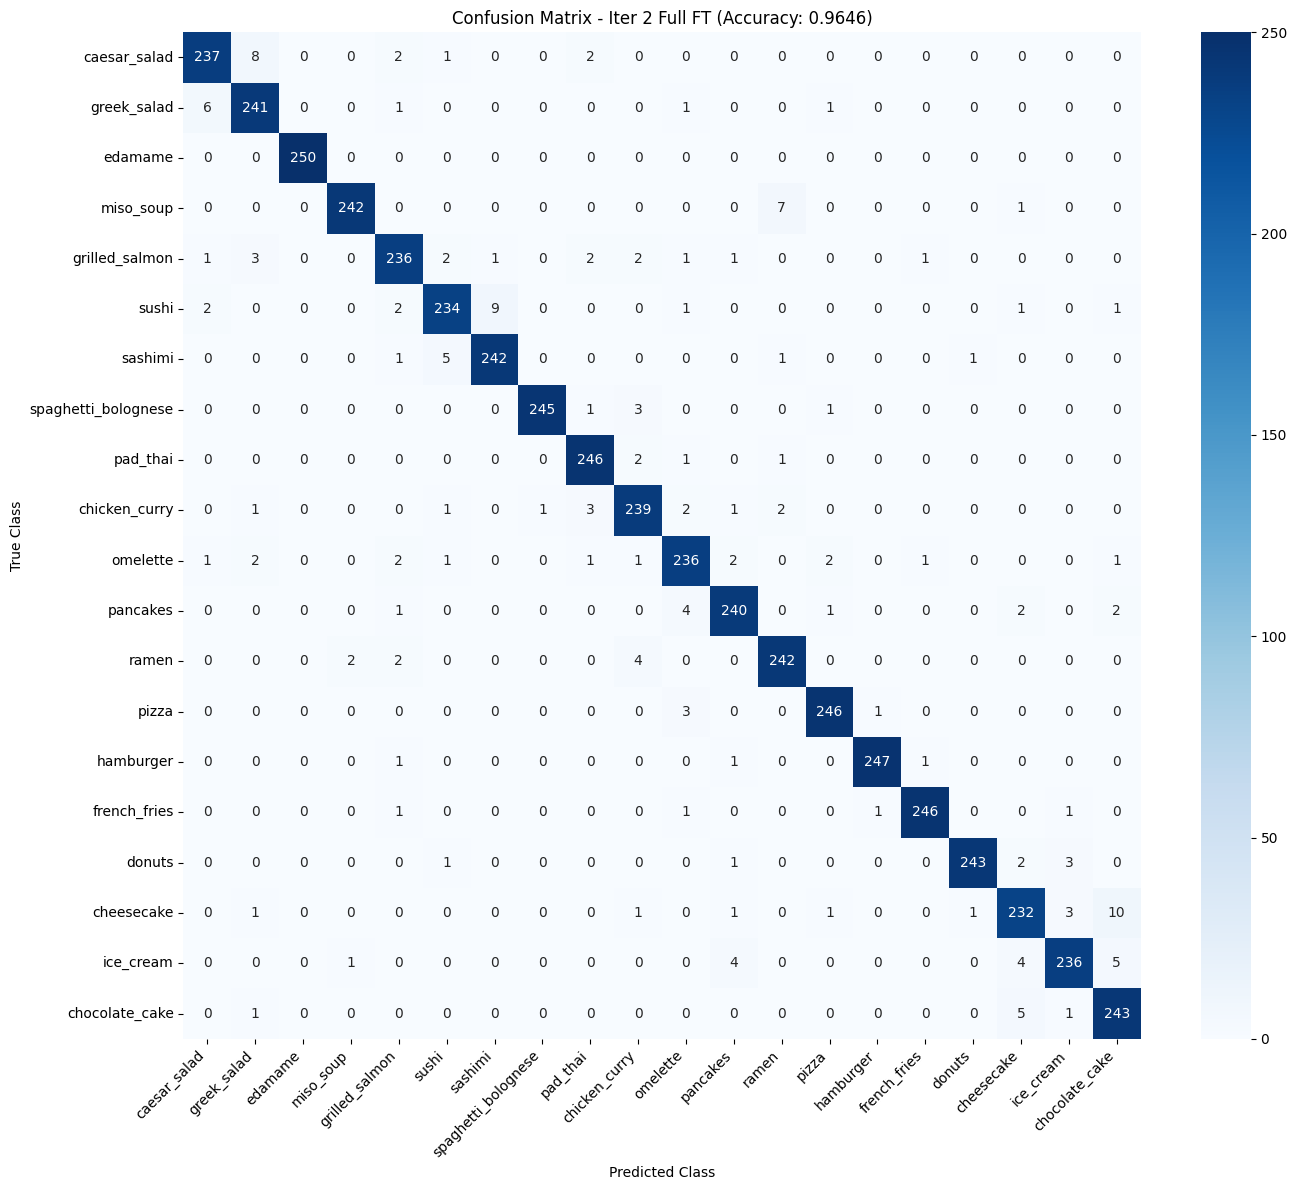


Classification Report:
                     precision    recall  f1-score   support

       caesar_salad       0.96      0.95      0.95       250
        greek_salad       0.94      0.96      0.95       250
            edamame       1.00      1.00      1.00       250
          miso_soup       0.99      0.97      0.98       250
     grilled_salmon       0.95      0.94      0.95       250
              sushi       0.96      0.94      0.95       250
            sashimi       0.96      0.97      0.96       250
spaghetti_bolognese       1.00      0.98      0.99       250
           pad_thai       0.96      0.98      0.97       250
      chicken_curry       0.95      0.96      0.95       250
           omelette       0.94      0.94      0.94       250
           pancakes       0.96      0.96      0.96       250
              ramen       0.96      0.97      0.96       250
              pizza       0.98      0.98      0.98       250
          hamburger       0.99      0.99      0.99       250

In [21]:
cm = confusion_matrix(y_true, y_pred_2)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES,
            ax=ax, cbar=True)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_title(f"Confusion Matrix - Iter 2 Full FT (Accuracy: {acc_2:.4f})")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_2, target_names=SELECTED_CLASSES))

In [22]:
errors = []
for i in range(len(SELECTED_CLASSES)):
    for j in range(len(SELECTED_CLASSES)):
        if i != j and cm[i, j] > 0:
            errors.append({
                "True": SELECTED_CLASSES[i],
                "Predicted": SELECTED_CLASSES[j],
                "Count": cm[i, j],
                "Total in class": cm[i].sum(),
                "Error rate": f"{100*cm[i,j]/cm[i].sum():.1f}%",
            })

errors_df = pd.DataFrame(errors).sort_values("Count", ascending=False).head(10)
print("Top 10 Verwechslungen:")
display(errors_df)
errors_df.to_csv("/content/top_errors.csv", index=False)

Top 10 Verwechslungen:


,True,Predicted,Count,Total in class,Error rate
79,cheesecake,chocolate_cake,10,250,4.0%
21,sushi,sashimi,9,250,3.6%
0,caesar_salad,greek_salad,8,250,3.2%
8,miso_soup,ramen,7,250,2.8%
4,greek_salad,caesar_salad,6,250,2.4%
26,sashimi,sushi,5,250,2.0%
83,ice_cream,chocolate_cake,5,250,2.0%
85,chocolate_cake,cheesecake,5,250,2.0%
82,ice_cream,cheesecake,4,250,1.6%
53,pancakes,omelette,4,250,1.6%


In [23]:
from huggingface_hub import login
login()

In [25]:
# Save Model und Processor lokal
trainer_2.save_model("/content/smartplate-vit-food")
processor.save_pretrained("/content/smartplate-vit-food")

print("Model + processor gespeichert in /content/smartplate-vit-food")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + processor gespeichert in /content/smartplate-vit-food


In [26]:
from huggingface_hub import HfApi, create_repo

HF_USERNAME = "Gianone"
REPO_NAME = "smartplate-vit-food"
REPO_ID = f"{HF_USERNAME}/{REPO_NAME}"

# Create repo (falls noch nicht da)
try:
    create_repo(REPO_ID, repo_type="model", exist_ok=True)
    print(f"Repo {REPO_ID} bereit")
except Exception as e:
    print(f"Repo-Setup: {e}")

# Upload alles aus dem lokalen Folder
api = HfApi()
api.upload_folder(
    folder_path="/content/smartplate-vit-food",
    repo_id=REPO_ID,
    repo_type="model",
    commit_message="feat: ViT fine-tuned on Food-101 subset (20 classes) - Full FT, Acc 96.46%",
)

print(f"\nModel uploaded to: https://huggingface.co/{REPO_ID}")

Repo Gianone/smartplate-vit-food bereit


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...it-food/model.safetensors:   0%|          |  551kB /  343MB            

  ...it-food/training_args.bin:   7%|6         |   357B / 5.20kB            


Model uploaded to: https://huggingface.co/Gianone/smartplate-vit-food


In [27]:
from google.colab import files
files.download("/content/confusion_matrix.png")
files.download("/content/iteration_comparison.csv")
files.download("/content/top_errors.csv")
print("Files downloaded — speichere sie in assets/screenshots/cv/")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded — speichere sie in assets/screenshots/cv/
